# DEG analysis

In [1]:
import os
import warnings 
warnings.filterwarnings('ignore')

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
plt.rcParams['pdf.fonttype'] = 42
sc._settings.settings._vector_friendly=True

In [5]:
from datetime import datetime
date = datetime.today().strftime('%Y-%m-%d')

In [6]:
base_path = '/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/expr'

input_path = os.path.join(base_path, 'cell type classification')

out_path = os.path.join(base_path, 'DE analysis')
if not os.path.exists(out_path):
    os.mkdir(out_path)
    
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','fig.1')
# if not os.path.exists(fig_path):
#     os.mkdir(fig_path)

# sc.settings.figdir = fig_path

In [7]:
adata = sc.read_h5ad(os.path.join(base_path, '2025-04-11-finalized-ct-rgn.h5ad'))
adata

In [8]:
# Add norm1e3 layer
adata.layers['norm1e3'] = adata.layers['norm1e4'] / 10
adata_temp = adata.copy()

sc.pp.log1p(adata_temp, layer='norm1e3', base=2)
adata.layers['log2_norm1e3'] = adata_temp.layers['norm1e3']

del adata_temp

## 1. Generating DEG file

### 1.1 Combined DEG

In [ ]:
### Group all cells for major cell type
level_list = ['level_2','level_3']
for level in tqdm(level_list, desc="Processing Levels"):

    excel_writer = pd.ExcelWriter(os.path.join(out_path, f"{date}_{level}_combined_DEG.xlsx"), engine="xlsxwriter")

    for cell_type in tqdm(sorted(adata.obs[level].unique().tolist()), desc="Processing Cell Types", leave=False):
  
            sdata = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR')].copy()
            rdata = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO')].copy()

            sdata_rep1 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR') & (adata.obs['replicate'] == 'rep1')].copy()
            rdata_rep1 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO') & (adata.obs['replicate'] == 'rep1')].copy()

            sdata_rep2 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR') & (adata.obs['replicate'] == 'rep2')].copy()
            rdata_rep2 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO') & (adata.obs['replicate'] == 'rep2')].copy()

            MIN_CELLS = 10

            datasets = {'sdata': sdata, 'rdata': rdata, 'sdata_rep1': sdata_rep1, 'rdata_rep1': rdata_rep1, 
                    'sdata_rep2': sdata_rep2, 'rdata_rep2': rdata_rep2}
            
            if any(data.shape[0] < MIN_CELLS for data in datasets.values()):
                print(f"Skipping cell_type={cell_type}, level={level} due to insufficient cells.")
                continue
            
            sc.tl.rank_genes_groups(sdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
            sc.tl.rank_genes_groups(rdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
            sc.tl.rank_genes_groups(sdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
            sc.tl.rank_genes_groups(rdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
            sc.tl.rank_genes_groups(sdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
            sc.tl.rank_genes_groups(rdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')

            sdf = sc.get.rank_genes_groups_df(sdata, group="HET")
            rdf = sc.get.rank_genes_groups_df(rdata, group="HET")
            sdf_rep1 = sc.get.rank_genes_groups_df(sdata_rep1, group="HET")
            rdf_rep1 = sc.get.rank_genes_groups_df(rdata_rep1, group="HET")
            sdf_rep2 = sc.get.rank_genes_groups_df(sdata_rep2, group="HET")
            rdf_rep2 = sc.get.rank_genes_groups_df(rdata_rep2, group="HET")

            sdf_rep1 = sdf_rep1.add_suffix("_rep1")
            sdf_rep2 = sdf_rep2.add_suffix("_rep2")
            merged_sdf = sdf.merge(sdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(sdf_rep2, left_on="names", right_on="names_rep2", how="inner")
            merged_sdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)

            rdf_rep1 = rdf_rep1.add_suffix("_rep1")
            rdf_rep2 = rdf_rep2.add_suffix("_rep2")

            merged_rdf = rdf.merge(rdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(rdf_rep2, left_on="names", right_on="names_rep2", how="inner")
            merged_rdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)


            merged_sdf.to_excel(excel_writer, sheet_name=f"{cell_type.replace("/", "_").split('-')[0]}_STAR", index=False)
            merged_rdf.to_excel(excel_writer, sheet_name=f"{cell_type.replace("/", "_").split('-')[0]}_RIBO", index=False)

    excel_writer.close()

Processing Levels:   0%|          | 0/2 [00:00<?, ?it/s]

Processing Cell Types:   0%|          | 0/17 [00:00<?, ?it/s]

Processing Cell Types:   0%|          | 0/31 [00:00<?, ?it/s]

In [27]:
level_2_combined_DEG_dict = pd.read_excel(os.path.join(out_path,"2025-04-09_level_2_combined_DEG.xlsx"), sheet_name=None)

In [29]:
level_3_combined_DEG_dict = pd.read_excel(os.path.join(out_path,"2025-04-09_level_3_combined_DEG.xlsx"), sheet_name=None)

### 1.2 Region-specific DEG (cross validation with previous data)

In [8]:
rgn_dict = {'PFC': ['CTX_mPFC5', 'CTX_ILA2/3'],
            'SSC': ['CTX_L2/3','CTX_L4','CTX_L5','CTX_L6'],
            'ST': ['STR'],
            'HP': ['CTX_CA1', 'CTX_CA3', 'CTX_DG', 'CTX_HIP'],
            'TH': ['TH_1', 'TH_2', 'TH_EPI','TH_RT']
            }


In [11]:
### Group all cells for glial cell type
level_list = ['level_2']
for level in tqdm(level_list, desc="Processing Levels"):

    excel_writer = pd.ExcelWriter(os.path.join(out_path, f"{date}_{level}_region_DEG.xlsx"))

    for cell_type in tqdm(sorted(adata.obs[level].unique().tolist()), desc="Processing Cell Types", leave=False):
            
            for rgn in tqdm(list(rgn_dict.keys()), desc="Processing Regions", leave=False):
  
                sdata = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()
                rdata = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()

                sdata_rep1 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()
                rdata_rep1 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()

                sdata_rep2 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()
                rdata_rep2 = adata[(adata.obs[level] == cell_type) & (adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()

                MIN_CELLS = 10

                datasets = {'sdata': sdata, 'rdata': rdata, 'sdata_rep1': sdata_rep1, 'rdata_rep1': rdata_rep1, 
                        'sdata_rep2': sdata_rep2, 'rdata_rep2': rdata_rep2}

                if any(data.shape[0] < MIN_CELLS for data in datasets.values()):
                        print(f"Skipping cell_type={cell_type}, region={rgn} due to insufficient cells.")
                        continue  # Skip to the next iteration
                
                sc.tl.rank_genes_groups(sdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
                sc.tl.rank_genes_groups(rdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
                sc.tl.rank_genes_groups(sdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
                sc.tl.rank_genes_groups(rdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
                sc.tl.rank_genes_groups(sdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
                sc.tl.rank_genes_groups(rdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')

                sdf = sc.get.rank_genes_groups_df(sdata, group="HET")
                rdf = sc.get.rank_genes_groups_df(rdata, group="HET")
                sdf_rep1 = sc.get.rank_genes_groups_df(sdata_rep1, group="HET")
                rdf_rep1 = sc.get.rank_genes_groups_df(rdata_rep1, group="HET")
                sdf_rep2 = sc.get.rank_genes_groups_df(sdata_rep2, group="HET")
                rdf_rep2 = sc.get.rank_genes_groups_df(rdata_rep2, group="HET")

                sdf_rep1 = sdf_rep1.add_suffix("_rep1")
                sdf_rep2 = sdf_rep2.add_suffix("_rep2")
                merged_sdf = sdf.merge(sdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(sdf_rep2, left_on="names", right_on="names_rep2", how="inner")
                merged_sdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)

                rdf_rep1 = rdf_rep1.add_suffix("_rep1")
                rdf_rep2 = rdf_rep2.add_suffix("_rep2")

                merged_rdf = rdf.merge(rdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(rdf_rep2, left_on="names", right_on="names_rep2", how="inner")
                merged_rdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)


                merged_sdf.to_excel(excel_writer, sheet_name=f"{cell_type}_{rgn}_STAR", index=False)
                merged_rdf.to_excel(excel_writer, sheet_name=f"{cell_type}_{rgn}_RIBO", index=False)

    excel_writer.close()

In [11]:
excel_writer = pd.ExcelWriter(os.path.join(out_path, f"{date}_bulk_region_DEG.xlsx"))

        
for rgn in tqdm(list(rgn_dict.keys()), desc="Processing Regions", leave=False):

    sdata = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()
    rdata = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()

    sdata_rep1 = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()
    rdata_rep1 = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()

    sdata_rep2 = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()
    rdata_rep2 = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()

    MIN_CELLS = 10

    datasets = {'sdata': sdata, 'rdata': rdata, 'sdata_rep1': sdata_rep1, 'rdata_rep1': rdata_rep1, 
            'sdata_rep2': sdata_rep2, 'rdata_rep2': rdata_rep2}

    if any(data.shape[0] < MIN_CELLS for data in datasets.values()):
            print(f"Skipping cell_type={cell_type}, region={rgn} due to insufficient cells.")
            continue  # Skip to the next iteration
    
    sc.tl.rank_genes_groups(sdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(sdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata_rep1, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(sdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata_rep2, groupby='genotype', layer='log2_norm1e3', method='wilcoxon', reference='WT')

    sdf = sc.get.rank_genes_groups_df(sdata, group="HET")
    rdf = sc.get.rank_genes_groups_df(rdata, group="HET")
    sdf_rep1 = sc.get.rank_genes_groups_df(sdata_rep1, group="HET")
    rdf_rep1 = sc.get.rank_genes_groups_df(rdata_rep1, group="HET")
    sdf_rep2 = sc.get.rank_genes_groups_df(sdata_rep2, group="HET")
    rdf_rep2 = sc.get.rank_genes_groups_df(rdata_rep2, group="HET")

    sdf_rep1 = sdf_rep1.add_suffix("_rep1")
    sdf_rep2 = sdf_rep2.add_suffix("_rep2")
    merged_sdf = sdf.merge(sdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(sdf_rep2, left_on="names", right_on="names_rep2", how="inner")
    merged_sdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)

    rdf_rep1 = rdf_rep1.add_suffix("_rep1")
    rdf_rep2 = rdf_rep2.add_suffix("_rep2")

    merged_rdf = rdf.merge(rdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(rdf_rep2, left_on="names", right_on="names_rep2", how="inner")
    merged_rdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)


    merged_sdf.to_excel(excel_writer, sheet_name=f"{rgn}_STAR", index=False)
    merged_rdf.to_excel(excel_writer, sheet_name=f"{rgn}_RIBO", index=False)

excel_writer.close()

### 1.3 semi-bulk DEG

In [ ]:
adata = sc.read_h5ad(os.path.join(out_path,'2025-07-10-all-sample-grid-quantification-processed.h5ad'))
adata.obs['genotype'] = adata.obs['condition']

In [ ]:
rgn_dict = {'PFC': ['CTX_mPFC5', 'CTX_ILA2/3'],
            'SSC': ['CTX_L2/3','CTX_L4','CTX_L5','CTX_L6'],
            'ST': ['STR'],
            'HP': ['CTX_CA1', 'CTX_CA3', 'CTX_DG', 'CTX_HIP'],
            'TH': ['TH_1', 'TH_2', 'TH_EPI','TH_RT']
            }

In [ ]:
excel_writer = pd.ExcelWriter(os.path.join(out_path, f"{date}_bulk_all_reads_region_DEG.xlsx"))

        
for rgn in tqdm(list(rgn_dict.keys()), desc="Processing Regions", leave=False):

    sdata = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()
    rdata = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn]))].copy()

    sdata_rep1 = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()
    rdata_rep1 = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep1')].copy()

    sdata_rep2 = adata[(adata.obs['protocol'] == 'STAR')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()
    rdata_rep2 = adata[(adata.obs['protocol'] == 'RIBO')&(adata.obs['region_label'].isin(rgn_dict[rgn])) & (adata.obs['replicate'] == 'rep2')].copy()

    MIN_CELLS = 10

    datasets = {'sdata': sdata, 'rdata': rdata, 'sdata_rep1': sdata_rep1, 'rdata_rep1': rdata_rep1, 
            'sdata_rep2': sdata_rep2, 'rdata_rep2': rdata_rep2}

    if any(data.shape[0] < MIN_CELLS for data in datasets.values()):
            print(f"Skipping cell_type={cell_type}, region={rgn} due to insufficient cells.")
            continue  # Skip to the next iteration
    
    sc.tl.rank_genes_groups(sdata, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(sdata_rep1, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata_rep1, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(sdata_rep2, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')
    sc.tl.rank_genes_groups(rdata_rep2, groupby='genotype', layer='log2_norm1e4', method='wilcoxon', reference='WT')

    sdf = sc.get.rank_genes_groups_df(sdata, group="HET")
    rdf = sc.get.rank_genes_groups_df(rdata, group="HET")
    sdf_rep1 = sc.get.rank_genes_groups_df(sdata_rep1, group="HET")
    rdf_rep1 = sc.get.rank_genes_groups_df(rdata_rep1, group="HET")
    sdf_rep2 = sc.get.rank_genes_groups_df(sdata_rep2, group="HET")
    rdf_rep2 = sc.get.rank_genes_groups_df(rdata_rep2, group="HET")

    sdf_rep1 = sdf_rep1.add_suffix("_rep1")
    sdf_rep2 = sdf_rep2.add_suffix("_rep2")
    merged_sdf = sdf.merge(sdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(sdf_rep2, left_on="names", right_on="names_rep2", how="inner")
    merged_sdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)

    rdf_rep1 = rdf_rep1.add_suffix("_rep1")
    rdf_rep2 = rdf_rep2.add_suffix("_rep2")

    merged_rdf = rdf.merge(rdf_rep1, left_on="names", right_on="names_rep1", how="inner").merge(rdf_rep2, left_on="names", right_on="names_rep2", how="inner")
    merged_rdf.drop(columns=["names_rep1", "names_rep2"], inplace=True)


    merged_sdf.to_excel(excel_writer, sheet_name=f"{rgn}_STAR", index=False)
    merged_rdf.to_excel(excel_writer, sheet_name=f"{rgn}_RIBO", index=False)

excel_writer.close()

## 2. DEG filtering bsed on NMF modules

### 2.1 Load NMF results

In [ ]:
base_path = '/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'

input_path = os.path.join(base_path, 'output/nmf/All_run')

out_path = os.path.join(base_path, 'expr/DE analysis/nmf')
if not os.path.exists(out_path):
    os.mkdir(out_path)
    
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
# Load the GEP scores
gep_scores = pd.read_csv(os.path.join(input_path, 'All_run_gep_scores.csv'), index_col=0)
top_genes = pd.read_csv(os.path.join(input_path, 'All_run_topgenes.csv'), index_col=0)

In [ ]:
sorted_genes_per_group = {
    col: gep_scores[col].sort_values(ascending=False).index.tolist()
    for col in gep_scores.columns
}
ranked_genes_df = pd.DataFrame(sorted_genes_per_group)
ranked_genes_df.index = range(1, len(ranked_genes_df) + 1)

ranked_genes_df

In [ ]:
processes_ratio_df = pd.read_csv(os.path.join(base_path, 'output/2025-06-02-Gene-Processes-Rank.csv'), index_col=0)

In [ ]:
# Create a mapping from gene name to mean
gene_to_mean = processes_ratio_df['mean'].to_dict()

# Replace gene names in every column of ranked_genes_df
ranked_genes_df_replaced = ranked_genes_df.replace(gene_to_mean)

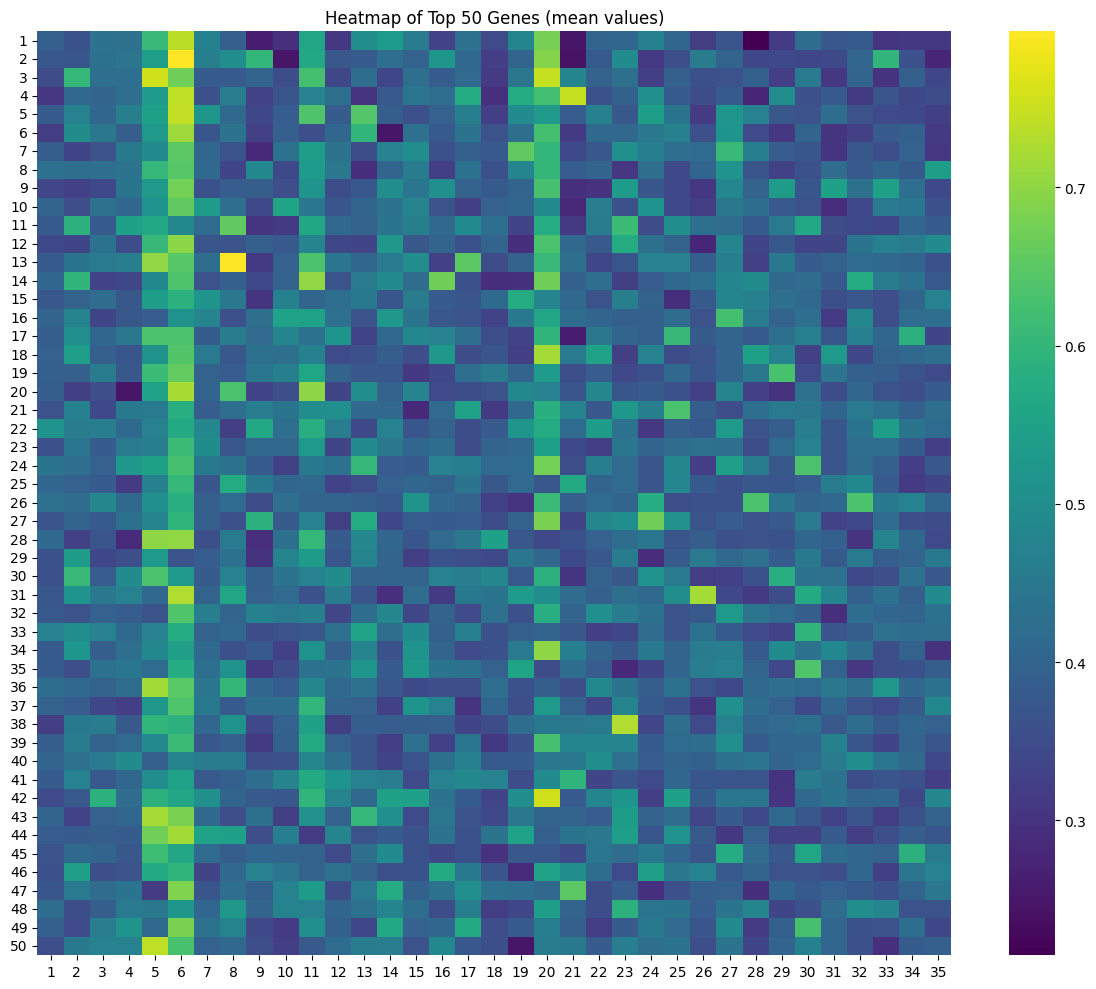

In [ ]:
top50 = ranked_genes_df_replaced.head(50)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(top50, cmap='viridis', annot=False)
plt.title('Heatmap of Top 50 Genes (mean values)')
plt.tight_layout()
plt.show()

### 2.2 DEG filtering

In [ ]:
level_2_combined_DEG_dict = pd.read_excel(os.path.join(base_path,'expr/DE analysis',"2025-04-09_level_2_combined_DEG.xlsx"), sheet_name=None)
level_3_combined_DEG_dict = pd.read_excel(os.path.join(base_path,'expr/DE analysis',"2025-04-09_level_3_combined_DEG.xlsx"), sheet_name=None)

In [ ]:
level_2_region_DEG_dict = pd.read_excel(os.path.join(base_path,'expr/DE analysis',"2025-08-11_level_2_region_DEG.xlsx"), sheet_name=None)

In [ ]:
glials = ['AC','OLG','OPC','MGL','CHOR','PER','VEN','VLM','VSM']

In [ ]:
def filter_consistent_deg(df, lfc_threshold=0.2, pval_threshold=0.05, rep_filter = True):
    """Filter genes that are significantly differentially expressed in both replicates with consistent LFC sign."""
    
    if rep_filter:
        return df.loc[
            (abs(df['logfoldchanges']) >= lfc_threshold) & 
            (df['pvals_adj'] < pval_threshold) &
            (
                # If both reps are significant, then require same LFC sign
                (
                    (df['pvals_adj_rep1'] < pval_threshold) & 
                    (df['pvals_adj_rep2'] < pval_threshold) &
                    ((df['logfoldchanges_rep1'] > 0) == (df['logfoldchanges_rep2'] > 0))
                )
                |
                # Otherwise, don't enforce LFC sign match
                (
                    (df['pvals_adj_rep1'] >= pval_threshold) |
                    (df['pvals_adj_rep2'] >= pval_threshold)
                )
            ),
            "names"
        ].tolist()
    
    else:
        return df.loc[
            (abs(df['logfoldchanges']) >= lfc_threshold) & 
            (df['pvals_adj'] < pval_threshold),
            "names"
        ].tolist()

In [ ]:
nmf_neuron_gene_to_exclude = list(
    set(ranked_genes_df['2'].head(40)) |
    set(ranked_genes_df['3'].head(40)) |
    set(ranked_genes_df['6'].head(20))
)

nmf_mix_gene_to_exclude = list(
    set(ranked_genes_df['3'].head(40))
)

In [ ]:
filtered_dict = {}

for sheet_name, df in level_2_combined_DEG_dict.items():
    cell_type = sheet_name.split('_')[0]

    # Apply filtering
    genes_filtered = filter_consistent_deg(df,lfc_threshold=0.2, pval_threshold=0.05, rep_filter = True)
    df_filtered = df[df['names'].isin(genes_filtered)]

    if cell_type in glials:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_neuron_gene_to_exclude)]
    else:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_mix_gene_to_exclude)]

    filtered_dict[sheet_name] = df_filtered


In [ ]:
# Save to Excel
with pd.ExcelWriter(os.path.join(out_path,f'{date}_level_2_nmf_filtered_DEG.xlsx')) as writer:
    for sheet_name, df in filtered_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)


In [ ]:
filtered_dict_lvl_3 = {}

for sheet_name, df in level_3_combined_DEG_dict.items():
    cell_type = sheet_name.split('_')[0]

    # Apply filtering
    genes_filtered = filter_consistent_deg(df,lfc_threshold=0.2, pval_threshold=0.05, rep_filter = True)
    df_filtered = df[df['names'].isin(genes_filtered)]

    if cell_type in glials:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_neuron_gene_to_exclude)]
    else:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_mix_gene_to_exclude)]

    filtered_dict_lvl_3[sheet_name] = df_filtered

In [ ]:
# Save to Excel
with pd.ExcelWriter(os.path.join(out_path,f'{date}_level_3_nmf_filtered_DEG.xlsx')) as writer:
    for sheet_name, df in filtered_dict_lvl_3.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

In [ ]:
filtered_dict = {}

for sheet_name, df in level_2_region_DEG_dict.items():
    cell_type = sheet_name.split('_')[0]

    # Apply filtering
    genes_filtered = filter_consistent_deg(df,lfc_threshold=0.2, pval_threshold=0.05, rep_filter = True)
    df_filtered = df[df['names'].isin(genes_filtered)]

    if cell_type == 'Mix':
        continue
    if cell_type in glials:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_neuron_gene_to_exclude)]
    else:
        df_filtered = df_filtered[~df_filtered['names'].isin(nmf_mix_gene_to_exclude)]

    if df_filtered.empty:
        print(f"No significant genes found for {sheet_name} after filtering.")
        continue
    filtered_dict[sheet_name] = df_filtered


No significant genes found for AC_PFC_STAR after filtering.
No significant genes found for CHOR_PFC_STAR after filtering.
No significant genes found for CHOR_PFC_RIBO after filtering.
No significant genes found for CHOR_SSC_STAR after filtering.
No significant genes found for CHOR_ST_STAR after filtering.
No significant genes found for CHOR_ST_RIBO after filtering.
No significant genes found for CHOR_HP_STAR after filtering.
No significant genes found for CHOR_HP_RIBO after filtering.
No significant genes found for CHOR_TH_RIBO after filtering.
No significant genes found for DEGLU_SSC_RIBO after filtering.
No significant genes found for DEGLU_ST_STAR after filtering.
No significant genes found for DEGLU_ST_RIBO after filtering.
No significant genes found for DEGLU_HP_STAR after filtering.
No significant genes found for DEGLU_HP_RIBO after filtering.
No significant genes found for DGGRC_PFC_STAR after filtering.
No significant genes found for DGGRC_PFC_RIBO after filtering.
No significa

In [ ]:
# Save to Excel
with pd.ExcelWriter(os.path.join(out_path,f'{date}_level_2_nmf_filtered_region_DEG.xlsx')) as writer:
    for sheet_name, df in filtered_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)


## 3. Visualization

### 3.1 Load DEG files

In [ ]:
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf','DEG 2D')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
level_2_combined_DEG_dict = pd.read_excel(os.path.join(base_path,'expr/DE analysis',"2025-04-09_level_2_combined_DEG.xlsx"), sheet_name=None)
level_3_combined_DEG_dict = pd.read_excel(os.path.join(base_path,'expr/DE analysis',"2025-04-09_level_3_combined_DEG.xlsx"), sheet_name=None)

In [ ]:
level_2_DEG_dict_filtered = pd.read_excel(os.path.join(out_path,f'2025-06-18_level_2_nmf_filtered_DEG.xlsx'), sheet_name=None)
level_3_DEG_dict_filtered = pd.read_excel(os.path.join(out_path,f'2025-06-18_level_3_nmf_filtered_DEG.xlsx'), sheet_name=None)


In [ ]:
ARG_list = [
    'Egr4', 'Fosb', 'Npas4', 'Fos', 'Btg2', 'Ier2', 'Amigo3', 'Egr3', 'Dusp1', 'Klf4', 
    'Arc', 'Gadd45g', 'Ppp1r15a', 'Egr2', 'Dusp5', 'Maff', 'Junb', 'Nr4a1', 'Egr1', 'Fndc9', 
    'Scg2', 'Glt28d2', 'Mbnl2', 'Maml3', 'Csrnp1', 'Sv2c', 'Hsd17b12', 'Crhbp', 'Col10a1', 'Gch1', 
    'Tac1', 'Errfi1', 'C2cd4b', 'Prok2', 'Slc2a3', 'Cartpt', 'Kcnj3', 'Chrm2', 'Mlf1', 'Dusp4', 
    'Popdc3', 'Ccdc184', 'Dusp14', 'Kcnf1', 'Alpk1', 'Rgs2', 'Wdr90', 'Grasp', 'Coq10b', 'Fam126b', 
    'Mctp2', 'Bdnf', 'Gem', 'Tiparp', 'Gpr22', 'Pcsk1', 'Cystm1', 'Ptgs2', 'Dmxl1', 'Per1', 
    'Cdkn1a', 'Ptger4', 'Fbxo33', 'Adm', 'Sik1', 'Pax1', 'Crem', 'Pou3f1', 'Spty2d1', 'Chst8', 
    'Tbc1d8b', 'Pgap1', 'Zdbf2', 'Lipg', 'Bves', 'Adcyap1', 'Chml', 'Slc7a1', 'Klf14', 'Pcdh8', 
    'Rgs4', 'Areg', 'Rnf128', 'Nap1l5', 'Peg10', 'Tnn', 'Nr4a3', 'Stk40', 'Atp10d', 'Rel', 
    'Slc6a17', 'Slc40a1', 'Mthfd2', 'Brinp1', 'Nrn1', 'Per2', 'Msantd1', 'Rem2', 'Gprc5a', 'Eprs', 
    'Pam', 'Sertad1', 'Tacr3', 'Hcrtr2', 'Herpud1', 'Stard4', 'Nppc', 'Pard6a', 'Plagl1', 'Pcdh20', 
    'Osgin2', 'Mpp7', 'Kcns2', 'Cort', 'Sstr2', 'Ell2', 'Gpr26', 'Sult2b1', 'Rheb', 'Acsl4', 
    'Nr4a2', 'Nefl', 'Fosl2', 'Tec', 'Fam46a', 'Gmeb2', 'Rasgrp1', 'Gltscr2', 'Atf3', 'Kitl', 
    'Baz1a', 'Npbwr1', '4931440P22Rik', 'Cfap43', 'D16Ertd472e', 'Meox1', 'Kcnj4', 'Gpr3', 'Trip10', 
    'Cd109', 'Gpr63', 'Tll1', 'Bmp3', 'Stc1', 'Klhl4', 'Sostdc1', 'Spred3', 'Sowahb', 'Slitrk4', 
    'Mfap3l', 'Kcna1', 'Fezf2', 'Dennd2c', 'Stc2', 'Hdac9', 'Hunk', 'Pthlh', 'Pnoc', 'Kcnh8', 
    'Acan', 'Gper1', 'Omg', 'Chac1', 'Stac', 'Nptx2', 'Kcna4', 'Sema3e', 'Palmd', 'Rab39', 
    'Serpinb2', 'Hspb3', '5430416O09Rik', '9430020K01Rik'
]

creb_target_genes = [
    "Tcf8", "Znf331", "Sod2", "Sgk", "Areg", "Nr4A1", "Gem", "Atf3", "Ptger3", "Il1A",
    "Vnn3", "Rtp801", "Mgc4504", "Rrad", "Tiparp", "Fos", "Epha2", "Adm", "Arhe", "Cebpb",
    "Vip32", "Ocm", "Nup50", "Arhb", "Rgs1", "Cmkor1", "Hk2", "Nfil3", "Flj21870", "Tgif",
    "Dkfzp434F0318", "Piga", "Rgs2", "Tob1", "Clecsf2", "Spry2", "G1P2", "Pim1", "Hist1H4E",
    "Pfkfb3", "Birc3", "Il6", "Pck1", "Zfp36L2", "Daf", "Plab", "Nedd9", "Plaur", "Efna1",
    "Stk22B", "Cks2", "Inhba", "Bmp8B", "Cebpd", "Ror1", "C14Orf113", "Ddit3", "Jmjd1",
    "Bcl2", "Id2B", "Nr4A3", "Snrk", "Zfp36L1", "Vegf", "Socs3", "Ly64", "G0S2", "Sbbi26",
    "C8Orf4", "Hmgb2", "Hig2", "Hspa6", "Tnc", "Lif", "Ptenp1", "Ugcg", "Upp1", "His1",
    "Bmp2", "Ereg", "Kiss1", "Riok3", "Htn3", "Znf288", "Pmaip1", "Hspa1A"
]

ribosomal_genes =['Apod', 'Ddx3x','Eif2a','Gcn1','Mrpl58',
 'Nufip2',
 'Rpl13a',
 'Rpl17',
 'Rpl32',
 'Rpl37a',
 'Rps12',
 'Rps24',
 'Rps5',
 'Rps7',
 'Rps8']


### 3.2 level_2 neuron type

In [ ]:
current_ct = 'TEINH'
sdf_het= level_2_combined_DEG_dict[f'{current_ct}_STAR']
rdf_het= level_2_combined_DEG_dict[f'{current_ct}_RIBO']

In [ ]:
s_deg_df = level_2_DEG_dict_filtered[f'{current_ct}_STAR']
r_deg_df = level_2_DEG_dict_filtered[f'{current_ct}_RIBO']
s_deg = level_2_DEG_dict_filtered[f'{current_ct}_STAR']['names'].tolist()
r_deg = level_2_DEG_dict_filtered[f'{current_ct}_RIBO']['names'].tolist()
overlap_deg = [gene for gene in s_deg if gene in r_deg]

3300
27
105
15


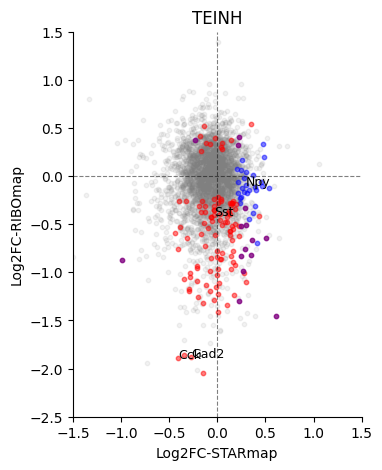

In [ ]:
# Merge the filtered dataframes on gene names
merged_df = pd.merge(sdf_het, rdf_het, on='names', suffixes=('_star', '_ribo'))

s_deg_set = set(s_deg)
r_deg_set = set(r_deg)

# Initialize group
merged_df['group'] = 'non-DEG'

# Assign groups based on set logic
merged_df.loc[merged_df['names'].isin(s_deg_set - r_deg_set), 'group'] = 'STARmap DEG'
merged_df.loc[merged_df['names'].isin(r_deg_set - s_deg_set), 'group'] = 'RIBOmap DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set & r_deg_set), 'group'] = 'Common DEG'

# Define colors for each group
color_map = {
    'STARmap DEG': 'blue',
    'RIBOmap DEG': 'red',
    'Common DEG': 'purple',
    'non-DEG': 'grey'
}

alpha_map = {
    'STARmap DEG': 0.5,
    'RIBOmap DEG': 0.5,
    'Common DEG': 0.8,
    'non-DEG': 0.1
}

# Create a color column using the map
merged_df['color'] = merged_df['group'].map(color_map)
merged_df['alpha'] = merged_df['group'].map(alpha_map)

# Plot the scatter plot
plt.figure(figsize=(5, 5))
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for group, color in [ ('non-DEG', 'grey'),('STARmap DEG', 'blue'), ('RIBOmap DEG', 'red'), ('Common DEG', 'purple')]:
    subset = merged_df[merged_df['group'] == group]
    plt.scatter(subset['logfoldchanges_star'], subset['logfoldchanges_ribo'], 
                s=10, c=color, alpha=alpha_map[group], label=group)


plt.xlabel('Log2FC-STARmap')
plt.ylabel('Log2FC-RIBOmap')
plt.title(f'{current_ct}')

# Annotate points with gene names
annotation_glist = ['Grin2a','Arc','Egr1','Egr3','Camk2a','Cnr1','Nrgn','Camk2b','Ppp3ca','Scn8a','Cadm3','Fos',
                    'Grin2b','Grin1','Gria2','Gria3','Grm3','Grm5', 'Slc17a7', 'Dlg1','Dlg2','Dlgap3','Shank2',
                    'Nrxn1','Nrxn2','Camk2g','Homer1','Nrn1','Kcnh4','Slc6a1'] # TEGLU
annotation_glist = ['Grin2a','Gad2','Gad1','Sst','Pvalb','Npy','Cck','Vip','Htr3a','Syt6','Reln','Fos'] # TEINH
# annotation_glist = ['Grin2a','Arc','Egr1','Egr3','Camk2a','Fos','Camk2b','Ppp3ca','Dlgap3','Cst3','Synpr','Drd1','Pdyn','Drd2','Penk','Adora2a'
#                     ,'Ppp1r1b', 'Rasd2', 'Pde10a', 'Foxp1', 'Ctip2', 'Gpr88','Comt', 'Gad1','Gad2'] # MSN
# annotation_glist = ['Nptx2', 'Nrn1', 'Rgs16','Camk2a','Rheb','Kif1a','Map1b','Ppp3ca','Sparc','Prkcd','Arc',
#                     "Slc17a6", "Tcf7l2", "Gbx2", "Pcp4", "Prkcd", "Synpo2",
#     "Cacna1g", "Cacna1i", "Hcn2", "Hcn4", "Kcnq2", "Kcnq3", "Kcna1", "Kcnd2", "Scn8a", "Kcnk3",
#     "Gria1", "Gria2", "Grik4", "Grik5", "Grm1", "Grm5", "Gabra1", "Gabra4", "Gabrb2", "Gabrg2", "Gphn",
#     "Robo1", "Robo2", "Dcc", "Epha4", "Epha5", "Efna5",
#     "Calb2", "Pvalb"] #DEGLU

# Get top/bottom 5 by each logFC column
top_genes = (
    list(s_deg_df.nlargest(5, 'logfoldchanges')['names']) +
    list(s_deg_df.nsmallest(5, 'logfoldchanges')['names']) +
    list(r_deg_df.nlargest(5, 'logfoldchanges')['names']) +
    list(r_deg_df.nsmallest(5, 'logfoldchanges')['names'])
)

annotation_glist = [gene for gene in annotation_glist if gene in set(s_deg) | set(r_deg)]

texts = []
for i, gene in enumerate(annotation_glist):
        text = plt.text(merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_star'].values[0], 
                merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_ribo'].values[0], 
                gene, fontsize=9,fontweight='medium', color='black')

        texts.append(text)

# Show the plot
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-2.5, 1.5)
ax.set_aspect('equal')
ax.grid(False)
plt.savefig(os.path.join(fig_path,f'{date}-{current_ct}.pdf'), format='pdf', dpi=300)
plt.show()

In [ ]:
# Plotly reference for gene annotation
merged_df = pd.merge(sdf_het, rdf_het, on='names', suffixes=('_star', '_ribo'))

s_deg_set = set(s_deg)
r_deg_set = set(r_deg)

merged_df['group'] = 'non-DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set - r_deg_set), 'group'] = 'STARmap DEG'
merged_df.loc[merged_df['names'].isin(r_deg_set - s_deg_set), 'group'] = 'RIBOmap DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set & r_deg_set), 'group'] = 'Common DEG'

color_map = {
    'STARmap DEG': 'blue',
    'RIBOmap DEG': 'red',
    'Common DEG': 'purple',
    'non-DEG': 'grey'
}
alpha_map = {
    'STARmap DEG': 0.5,
    'RIBOmap DEG': 0.5,
    'Common DEG': 0.8,
    'non-DEG': 0.1
}
size_map = {
    'STARmap DEG': 7,
    'RIBOmap DEG': 7,
    'Common DEG': 8,
    'non-DEG': 6
}

merged_df['color'] = merged_df['group'].map(color_map)
merged_df['alpha'] = merged_df['group'].map(alpha_map)
merged_df['size']  = merged_df['group'].map(size_map)

# Annotate points with gene names
annotation_glist = ['Grin2a','Arc','Egr1','Egr3','Camk2a','Cnr1','Nrgn','Camk2b','Ppp3ca','Scn8a','Cadm3','Fos'] # TEGLU
annotation_glist = ['Gad2','Gad1','Sst','Pvalb','Npy','Cck','Vip','Htr3a','Syt6','Reln','Fos',''] # TEINH
annotation_glist = ['Grin2a','Arc','Egr1','Egr3','Camk2a','Fos','Camk2b','Ppp3ca','Dlgap3','Cst3','Synpr','Drd1','Pdyn','Drd2','Penk','Adora2a'
                    ,'Ppp1r1b', 'Rasd2', 'Pde10a', 'Foxp1', 'Ctip2', 'Gpr88'] # MSN
annotation_glist = ['Nptx2', 'Nrn1', 'Rgs16','Camk2a','Rheb','Kif1a','Map1b','Ppp3ca','Sparc','Prkcd','Arc',
                    "Slc17a6", "Tcf7l2", "Gbx2", "Pcp4", "Prkcd", "Synpo2",
    "Cacna1g", "Cacna1i", "Hcn2", "Hcn4", "Kcnq2", "Kcnq3", "Kcna1", "Kcnd2", "Scn8a", "Kcnk3",
    "Gria1", "Gria2", "Grik4", "Grik5", "Grm1", "Grm5", "Gabra1", "Gabra4", "Gabrb2", "Gabrg2", "Gphn",
    "Robo1", "Robo2", "Dcc", "Epha4", "Epha5", "Efna5",
    "Calb2", "Pvalb"] #DEGLU


# Get top/bottom 5 by each logFC column
top_genes = (
    list(s_deg_df.nlargest(5, 'logfoldchanges')['names']) +
    list(s_deg_df.nsmallest(5, 'logfoldchanges')['names']) +
    list(r_deg_df.nlargest(5, 'logfoldchanges')['names']) +
    list(r_deg_df.nsmallest(5, 'logfoldchanges')['names'])
)

# Final unique list
annotation_glist = [gene for gene in annotation_glist if gene in set(s_deg) | set(r_deg)]
annotation_glist = list(set(annotation_glist + top_genes))

# Keep only genes that are DE in either platform and present in merged_df
annotation_glist = [g for g in annotation_glist if g in (s_deg_set | r_deg_set)]
ann_df = merged_df[merged_df['names'].isin(annotation_glist)].copy()

# --- Axis ranges (match your [-2.5, 2.5]) ---
x_min, x_max = -1.5, 1.5
y_min, y_max = -2.5, 1.5

# --- (Optional) correlation (overall, on finite points) ---
x_vals = merged_df['logfoldchanges_star'].astype(float).replace([np.inf,-np.inf], np.nan)
y_vals = merged_df['logfoldchanges_ribo'].astype(float).replace([np.inf,-np.inf], np.nan)
mask = x_vals.notna() & y_vals.notna()
r_value = float(np.corrcoef(x_vals[mask], y_vals[mask])[0,1]) if mask.sum() > 1 else np.nan

# --- Build figure ---
fig = go.Figure()

# Plot order: non-DEG first so DEG overlays appear on top
plot_order = ['non-DEG', 'STARmap DEG', 'RIBOmap DEG', 'Common DEG']

for grp in plot_order:
    sub = merged_df[merged_df['group'] == grp]
    fig.add_trace(
        go.Scattergl(
            x=sub['logfoldchanges_star'],
            y=sub['logfoldchanges_ribo'],
            mode='markers',
            name=grp,
            marker=dict(
                color=color_map[grp],
                size=size_map[grp],
                opacity=alpha_map[grp],
                line=dict(width=0)
            ),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "Log2FC-STARmap: %{x:.3f}<br>"
                "Log2FC-RIBOmap: %{y:.3f}<br>"
                "Group: " + grp + "<extra></extra>"
            ),
            customdata=np.stack([sub['names']], axis=-1),
        )
    )

# Text labels as a separate trace you can toggle via legend
if not ann_df.empty:
    fig.add_trace(
        go.Scattergl(
            x=ann_df['logfoldchanges_star'],
            y=ann_df['logfoldchanges_ribo'],
            mode='text',
            name='Annotations',
            text=ann_df['names'],
            textposition='top center',
            textfont=dict(size=11, color='black'),
            hoverinfo='skip',
            showlegend=True
        )
    )

# Axes lines at 0 and the identity line y=x
fig.update_layout(
    shapes=[
        # y = 0
        dict(type='line', x0=x_min, x1=x_max, y0=0, y1=0,
             line=dict(color='black', width=1, dash='dash')),
        # x = 0
        dict(type='line', x0=0, x1=0, y0=y_min, y1=y_max,
             line=dict(color='black', width=1, dash='dash')),
        # y = x
        dict(type='line', x0=x_min, x1=x_max, y0=x_min, y1=x_max,
             line=dict(color='gray', width=1, dash='dot')),
    ]
)

# Equal aspect, tidy theme, fixed ranges
title_suffix = f" | r = {r_value:.2f}" if not np.isnan(r_value) else ""
fig.update_layout(
    title=f"{current_ct}{title_suffix}",
    xaxis_title="Log2FC-STARmap",
    yaxis_title="Log2FC-RIBOmap",
    template="none",
    width=600, height=600,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=60, b=60)
)
fig.update_xaxes(range=[x_min, x_max], zeroline=False, showgrid=False, scaleanchor="y", scaleratio=1.0)
fig.update_yaxes(range=[y_min, y_max], zeroline=False, showgrid=False)

fig.show()


### 3.3 level_3 neuron subtype

In [ ]:
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf','DEG 2D','level3',)
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
current_ct = 'HABCHO'
sdf_het= level_3_combined_DEG_dict[f'{current_ct}_STAR']
rdf_het= level_3_combined_DEG_dict[f'{current_ct}_RIBO']


In [ ]:
s_deg_df = level_3_DEG_dict_filtered[f'{current_ct}_STAR']
r_deg_df = level_3_DEG_dict_filtered[f'{current_ct}_RIBO']
s_deg = level_3_DEG_dict_filtered[f'{current_ct}_STAR']['names'].tolist()
r_deg = level_3_DEG_dict_filtered[f'{current_ct}_RIBO']['names'].tolist()
overlap_deg = [gene for gene in s_deg if gene in r_deg]

In [ ]:
# Merge the filtered dataframes on gene names
merged_df = pd.merge(sdf_het, rdf_het, on='names', suffixes=('_star', '_ribo'))

s_deg_set = set(s_deg)
r_deg_set = set(r_deg)

# Initialize group
merged_df['group'] = 'non-DEG'

# Assign groups based on set logic
merged_df.loc[merged_df['names'].isin(s_deg_set - r_deg_set), 'group'] = 'STARmap DEG'
merged_df.loc[merged_df['names'].isin(r_deg_set - s_deg_set), 'group'] = 'RIBOmap DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set & r_deg_set), 'group'] = 'Common DEG'

# Define colors for each group
color_map = {
    'STARmap DEG': 'blue',
    'RIBOmap DEG': 'red',
    'Common DEG': 'purple',
    'non-DEG': 'grey'
}

alpha_map = {
    'STARmap DEG': 0.5,
    'RIBOmap DEG': 0.5,
    'Common DEG': 0.8,
    'non-DEG': 0.1
}

# Create a color column using the map
merged_df['color'] = merged_df['group'].map(color_map)
merged_df['alpha'] = merged_df['group'].map(alpha_map)

# Plot the scatter plot
plt.figure(figsize=(5, 5))
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for group, color in [ ('non-DEG', 'grey'),('STARmap DEG', 'blue'), ('RIBOmap DEG', 'red'), ('Common DEG', 'purple')]:
    subset = merged_df[merged_df['group'] == group]
    plt.scatter(subset['logfoldchanges_star'], subset['logfoldchanges_ribo'], 
                s=10, c=color, alpha=alpha_map[group], label=group)


plt.xlabel('Log2FC-STARmap')
plt.ylabel('Log2FC-RIBOmap')
plt.title(f'{current_ct}')

# Annotate points with gene names
ARG_annotation_glist = [gene for gene in ARG_list if gene in s_deg_set | r_deg_set]
ribosome_annotation_glist = [gene for gene in ribosomal_genes if gene in s_deg_set | r_deg_set]

ARG_annotated_points = merged_df[merged_df['names'].isin(ARG_annotation_glist)]
ribosome_annotated_points = merged_df[merged_df['names'].isin(ribosome_annotation_glist)]

plt.scatter(
    ribosome_annotated_points['logfoldchanges_star'],
    ribosome_annotated_points['logfoldchanges_ribo'],
    s=40,                   
    facecolors='none',         
    edgecolors='#f7cf05',     
    linewidths=1.2,
    zorder=5             
)

plt.scatter(
    ARG_annotated_points['logfoldchanges_star'],
    ARG_annotated_points['logfoldchanges_ribo'],
    s=40,           
    facecolors='none',   
    edgecolors='black',       
    linewidths=1.2,
    zorder=5              
)

annotation_glist = list(set(ARG_annotation_glist + ribosome_annotation_glist))

texts = []
for i, gene in enumerate(annotation_glist):
        text = plt.text(merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_star'].values[0], 
                merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_ribo'].values[0], 
                gene, fontsize=9,fontweight='medium', color='black')

        texts.append(text)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(False)
plt.legend(loc='upper right')
plt.savefig(os.path.join(fig_path,f'{current_ct}.pdf'), format='pdf', dpi=300)
plt.show()

### 3.5 non-neuron cell type

In [ ]:
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf','DEG 2D','level2')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
# level 2 cell type
current_ct = 'OPC'
sdf_het= level_2_combined_DEG_dict[f'{current_ct}_STAR']
rdf_het= level_2_combined_DEG_dict[f'{current_ct}_RIBO']

s_deg_df = level_2_DEG_dict_filtered[f'{current_ct}_STAR']
r_deg_df = level_2_DEG_dict_filtered[f'{current_ct}_RIBO']
s_deg = level_2_DEG_dict_filtered[f'{current_ct}_STAR']['names'].tolist()
r_deg = level_2_DEG_dict_filtered[f'{current_ct}_RIBO']['names'].tolist()
overlap_deg = [gene for gene in s_deg if gene in r_deg]

In [ ]:
# Merge the filtered dataframes on gene names
merged_df = pd.merge(sdf_het, rdf_het, on='names', suffixes=('_star', '_ribo'))
s_deg_set = set(s_deg)
r_deg_set = set(r_deg)

# Initialize group
merged_df['group'] = 'non-DEG'

# Assign groups based on set logic
merged_df.loc[merged_df['names'].isin(s_deg_set - r_deg_set), 'group'] = 'STARmap DEG'
merged_df.loc[merged_df['names'].isin(r_deg_set - s_deg_set), 'group'] = 'RIBOmap DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set & r_deg_set), 'group'] = 'Common DEG'

# Define colors for each group
color_map = {
    'STARmap DEG': 'blue',
    'RIBOmap DEG': 'red',
    'Common DEG': 'purple',
    'non-DEG': 'grey'
}

alpha_map = {
    'STARmap DEG': 0.5,
    'RIBOmap DEG': 0.5,
    'Common DEG': 0.8,
    'non-DEG': 0.1
}

# Create a color column using the map
merged_df['color'] = merged_df['group'].map(color_map)
merged_df['alpha'] = merged_df['group'].map(alpha_map)

# Plot the scatter plot
plt.figure(figsize=(5, 5))
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for group, color in [ ('non-DEG', 'grey'),('STARmap DEG', 'blue'), ('RIBOmap DEG', 'red'), ('Common DEG', 'purple')]:
    subset = merged_df[merged_df['group'] == group]
    print(len(subset))
    plt.scatter(subset['logfoldchanges_star'], subset['logfoldchanges_ribo'], 
                s=10, c=color, alpha=alpha_map[group], label=group)


plt.xlabel('Log2FC-STARmap')
plt.ylabel('Log2FC-RIBOmap')
plt.title(f'{current_ct}')


annotation_glist = list(set( s_deg_set | r_deg_set))
texts = []
for i, gene in enumerate(annotation_glist):
        text = plt.text(merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_star'].values[0], 
                merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_ribo'].values[0], 
                gene, fontsize=9,fontweight='medium', color='black')

        texts.append(text)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.grid(False)
plt.savefig(os.path.join(fig_path,f'{current_ct}.pdf'), format='pdf', dpi=300)
plt.show()

In [ ]:
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf','DEG 2D','level3')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
# level 3 cell type
current_ct = 'AC_1'
sdf_het= level_3_combined_DEG_dict[f'{current_ct}_STAR']
rdf_het= level_3_combined_DEG_dict[f'{current_ct}_RIBO']

s_deg_df = level_3_DEG_dict_filtered[f'{current_ct}_STAR']
r_deg_df = level_3_DEG_dict_filtered[f'{current_ct}_RIBO']
s_deg = level_3_DEG_dict_filtered[f'{current_ct}_STAR']['names'].tolist()
r_deg = level_3_DEG_dict_filtered[f'{current_ct}_RIBO']['names'].tolist()
overlap_deg = [gene for gene in s_deg if gene in r_deg]

In [ ]:
# Merge the filtered dataframes on gene names
merged_df = pd.merge(sdf_het, rdf_het, on='names', suffixes=('_star', '_ribo'))
s_deg_set = set(s_deg)
r_deg_set = set(r_deg)

# Initialize group
merged_df['group'] = 'non-DEG'

# Assign groups based on set logic
merged_df.loc[merged_df['names'].isin(s_deg_set - r_deg_set), 'group'] = 'STARmap DEG'
merged_df.loc[merged_df['names'].isin(r_deg_set - s_deg_set), 'group'] = 'RIBOmap DEG'
merged_df.loc[merged_df['names'].isin(s_deg_set & r_deg_set), 'group'] = 'Common DEG'

# Define colors for each group
color_map = {
    'STARmap DEG': 'blue',
    'RIBOmap DEG': 'red',
    'Common DEG': 'purple',
    'non-DEG': 'grey'
}

alpha_map = {
    'STARmap DEG': 0.5,
    'RIBOmap DEG': 0.5,
    'Common DEG': 0.8,
    'non-DEG': 0.1
}

# Create a color column using the map
merged_df['color'] = merged_df['group'].map(color_map)
merged_df['alpha'] = merged_df['group'].map(alpha_map)

# Plot the scatter plot
plt.figure(figsize=(5, 5))
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for group, color in [ ('non-DEG', 'grey'),('STARmap DEG', 'blue'), ('RIBOmap DEG', 'red'), ('Common DEG', 'purple')]:
    subset = merged_df[merged_df['group'] == group]
    print(len(subset))
    plt.scatter(subset['logfoldchanges_star'], subset['logfoldchanges_ribo'], 
                s=10, c=color, alpha=alpha_map[group], label=group)


plt.xlabel('Log2FC-STARmap')
plt.ylabel('Log2FC-RIBOmap')
plt.title(f'{current_ct}')


annotation_glist = list(set( s_deg_set | r_deg_set))
texts = []
for i, gene in enumerate(annotation_glist):
        text = plt.text(merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_star'].values[0], 
                merged_df.loc[merged_df['names'] == gene, 'logfoldchanges_ribo'].values[0], 
                gene, fontsize=9,fontweight='medium', color='black')

        texts.append(text)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.grid(False)
plt.savefig(os.path.join(fig_path,f'{current_ct}.pdf'), format='pdf', dpi=300)
plt.show()

## 4. nerounal subtype DEG overview

In [ ]:
from upsetplot import from_contents, plot

In [ ]:
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','nmf','neuron subtype DEG')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [ ]:
major_ct = ['TEGLU','MSN','TEINH']

ribo_deg_dict = {}
star_deg_dict = {}

for current_ct in major_ct:
    key = current_ct.replace('/', '_') 
    s_deg = level_2_DEG_dict_filtered[f'{key}_STAR']['names'].tolist()
    r_deg = level_2_DEG_dict_filtered[f'{key}_RIBO']['names'].tolist()
    ribo_deg_dict[current_ct] = r_deg
    star_deg_dict[current_ct] = s_deg

In [ ]:
subtype_dict = {
    'TEGLU': ['TEGLU_L2/3','TEGLU_L4/5','TEGLU_L5/6','TEGLU_L6','TEGLU_CA'],
    'TEINH': ['TEINH_1','TEINH_2','TEINH_3','TEINH_4'],
    'MSN': ['MSN_1','MSN_2']
}

In [ ]:
deg_dict = {}

for current_major_ct in subtype_dict.keys():
    deg_dict_temp = {'STAR':{}, 'RIBO':{}}
    for current_ct in subtype_dict[current_major_ct]:
        key = current_ct.replace('/', '_') 
        s_deg = level_3_DEG_dict_filtered[f'{key}_STAR']['names'].tolist()
        r_deg = level_3_DEG_dict_filtered[f'{key}_RIBO']['names'].tolist()
        deg_dict_temp['STAR'][current_ct]= s_deg
        deg_dict_temp['RIBO'][current_ct]= r_deg

    deg_dict[current_major_ct] = deg_dict_temp

In [ ]:
for current_major_ct in subtype_dict.keys():
    for current_protocol in ['STAR','RIBO']:
        print(f'Processing {current_major_ct} {current_protocol}')
        gene_list_upset = from_contents(deg_dict[current_major_ct][current_protocol])
        print(gene_list_upset)
        idx_df = gene_list_upset.index.to_frame()      # keeps original MultiIndex as the row index

        gene_list_upset.index = pd.MultiIndex.from_frame(idx_df)

        plot(gene_list_upset, intersection_plot_elements=2, 
            show_counts=True)
        plt.savefig(os.path.join(fig_path,f'{current_major_ct}_{current_protocol}.pdf'), format='pdf', dpi=300)
        plt.show()

## 5. Grin2a basal level

In [ ]:
adata = sc.read_h5ad(os.path.join(base_path, '2025-04-11-finalized-ct-rgn.h5ad'))
adata

In [ ]:
wt_neuron = adata[(adata.obs['genotype']=='WT')&(adata.obs['level_1']=='Neuron')]
wt_neuron

View of AnnData object with n_obs × n_vars = 131691 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3_order', 'region_label_color_dict', 'region_label_order'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 

In [ ]:
# Basal Grin2a expression
excel_writer = pd.ExcelWriter(os.path.join(out_path, f"{date}_basal_Grin2a.xlsx"))
for protocol in ['STAR','RIBO']:
    grin2a_expr = wt_neuron[wt_neuron.obs['protocol'] == protocol][:, 'Grin2a'].layers['log2_norm1e4'].toarray().flatten()
    grin2a_df = pd.DataFrame({
        'cell_type': wt_neuron[wt_neuron.obs['protocol']==protocol].obs['level_3'], 
        'Grin2a_expression': grin2a_expr
    })

    avg_expr_df = grin2a_df.groupby('cell_type')['Grin2a_expression'].mean().reset_index()
    avg_expr_df.to_excel(excel_writer, sheet_name=f"{protocol}", index=False)
excel_writer.close()
    

In [ ]:
basal_grin2a_dict = pd.read_excel(os.path.join(out_path,'2025-04-17_basal_Grin2a.xlsx'), sheet_name=None)